# LRHS log 0003

Development log

## Table of Contents

## Test computing of wet natural freqs [2026-01-15]

### Testing the consequence on the membrane case from Agarwal (2023) paper

The test case was `mfac = 0.9, tfac = 0.1`.

For this, the dry natural freqs are


| dry $\omega_n$ | wet (damped) $\omega_n$ <br> Method 1<br> Complex Mass | wet (damped) $\omega_n$ <br> New Method | 
| --- | --- | --- |
| NA | NA |
| 1.6400 + 0.0000im | 1.55445-0.273424im |
| 3.2799 + 0.0000im | 2.4142-0.204969im |
| 4.9199 + 0.0000im | 3.4685-0.153279im |










In [6]:
using Pkg
Pkg.activate("/home/shagun/Acads/HydroElasticFEM.jl")

using HydroElasticFEM

PKG_ROOT = HydroElasticFEM.PKG_ROOT

  Activating project at `~/Acads/HydroElasticFEM.jl`


"/home/shagun/Acads/HydroElasticFEM.jl/"

In [7]:
using JLD2
using Printf
using DataFrames
using Plots

In [8]:
fileName = "data/sims_202512/mem_modes_free/run/"
fileName = fileName*"memb_free_mfac=0.90_tfac=0.10_modesdata.jld2"
df1 = load(PKG_ROOT*fileName)

@printf("Dry Natural Frequencies :\n")
(x -> @printf("%.4f + %.4fim\n", real(x), imag(x))).(df1["dfDry"][:,"ωn"])
println()

@printf("Wet Natural Frequencies :\n")
(x -> @printf("%.4f + %.4fim\n", real(x), imag(x))).(df1["dfWet"][:,"ωn"])
println()

nothing

┌ Warning: type Main.Membrane_modes.MembLR_params does not exist in workspace; reconstructing
└ @ JLD2 /home/shagun/.julia/packages/JLD2/SgtOb/src/data/reconstructing_datatypes.jl:588


Dry Natural Frequencies :
0.0000 + 0.0000im
1.6400 + 0.0000im
3.2799 + 0.0000im
4.9199 + 0.0000im

Wet Natural Frequencies :
0.0000 + 0.0000im
1.5544 + -0.2734im
2.4142 + -0.2050im
3.4685 + -0.1533im



In [9]:
fileName = "data/sims_202512/mem_modes_free/run/"
fileName = fileName*"memb_free_mfac=0.90_tfac=0.10_modesdata.jld2"
df2 = load(PKG_ROOT*fileName)

@printf("Dry Natural Frequencies :\n")
(x -> @printf("%.4f + %.4fim\n", real(x), imag(x))).(df2["dfDry"][:,"ωn"])
println()

@printf("Wet Natural Frequencies :\n")
(x -> @printf("%.4f + %.4fim\n", real(x), imag(x))).(df2["dfWet"][:,"ωn"])
println()

nothing

Dry Natural Frequencies :
0.0000 + 0.0000im
1.6400 + 0.0000im
3.2799 + 0.0000im
4.9199 + 0.0000im

Wet Natural Frequencies :
0.0000 + 0.0000im


┌ Warning: type Main.Membrane_modes.MembLR_params does not exist in workspace; reconstructing
└ @ JLD2 /home/shagun/.julia/packages/JLD2/SgtOb/src/data/reconstructing_datatypes.jl:588


1.5544 + -0.2734im
2.4142 + -0.2050im
3.4685 + -0.1533im



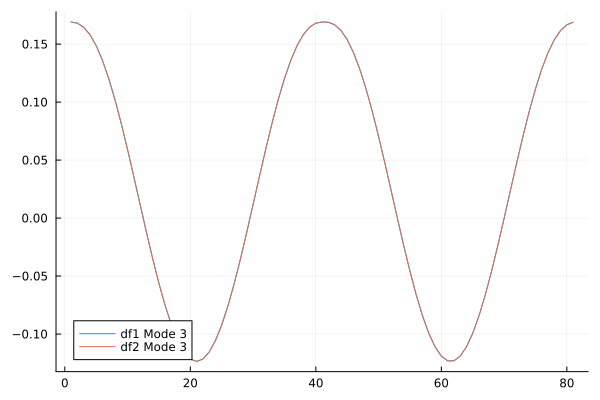

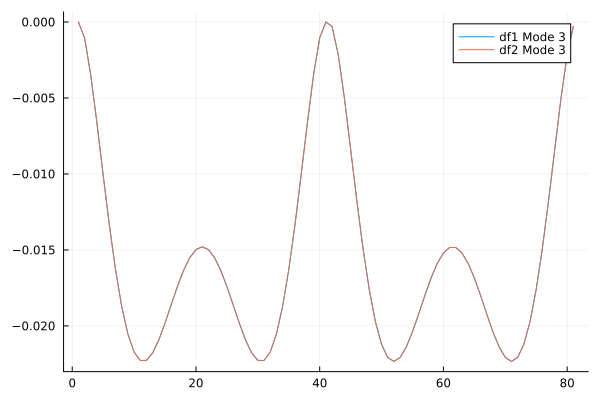

In [13]:
df1_mode = 3
df2_mode = 3

df1_V = df1["dfWet"][:,"V"][df1_mode]
df2_V = df2["dfWet"][:,"V"][df2_mode]

plot()
plot!(real(df1_V), label="df1 Mode $df1_mode")
plot!(real(df2_V), label="df2 Mode $df2_mode")
display(plot!())

plot()
plot!(imag(df1_V), label="df1 Mode $df1_mode")
plot!(imag(df2_V), label="df2 Mode $df2_mode")
display(plot!())
